# MERIDA HRES — 1h RP Maps: CLIMAAX-style fitting variant

**Purpose:** Drop-in alternative to the L-moments / constrained-MLE fitting in
`MERIDA_HRES_1h_RP_maps_v5.ipynb` that mirrors the **CLIMAAX Heavy Rainfall
Hazard Assessment** approach (CRAHI-UPC).

**Key differences from v5:**

| Aspect | v5 (your notebook) | This notebook (CLIMAAX-style) |
|---|---|---|
| GEV estimator | L-moments primary, MLE fallback | MLE only (`scipy.genextreme.fit`) |
| Shape constraint | Hard clip `ξ ∈ [−0.3, 0.1]` | None (unconstrained) |
| RP quantile formula | Coles (2001) exact inverse CDF | Chow (1988) log-space frequency factor |
| CI method | Bootstrap (500 resamples) | Analytical normal approximation |
| Goodness-of-fit | Visual validation | KS test statistic stored per pixel |

**Same as v5:** data loading, annual-maxima extraction, Italy land mask,
GeoTIFF export, validation plot, all user settings.

> **Scientific note:** The CLIMAAX frequency-factor formula is an approximation
> valid for log-normal/log-Pearson III; it only approximates GEV behaviour and
> diverges from the exact quantile for `ξ` far from zero.  See the comparison
> cell at the end of this notebook.


## 0 · Imports & configuration

In [1]:
import os
import re
import warnings
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask
from scipy.stats import genextreme as gev_scipy, ks_1samp

warnings.filterwarnings('ignore')

# ── USER SETTINGS (identical to v5 — change only here) ──────────────────────
DATA_DIR       = Path("/home/admin_climatecharted_com/data/MERIDA_HRES")
OUT_DIR        = Path("/home/admin_climatecharted_com/data/MERIDA_HRES/MERIDA_HRES_RP_climaax")
MASK_SHP       = Path("/home/admin_climatecharted_com/data/it_4326/it_4326.shp")
PREC_VAR       = "tp"
IS_ACCUMULATED = True
DURATION_H     = 1
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200]
# ─────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory : {OUT_DIR.resolve()}")


Output directory : /home/admin_climatecharted_com/data/MERIDA_HRES/MERIDA_HRES_RP_climaax


## 1 · Data inventory

Identical to v5.

In [2]:
files = sorted(DATA_DIR.glob("MERIDA_HRES_PREC_*.nc"))
print(f"Total files found: {len(files)}")

pat = re.compile(r"MERIDA_HRES_PREC_(\d{4})(\d{2})\.nc")
records = []
for f in files:
    m = pat.search(f.name)
    if m:
        records.append({"path": f, "year": int(m.group(1)), "month": int(m.group(2)),
                        "size_mb": f.stat().st_size / 1e6})

df_inv = pd.DataFrame(records).sort_values(["year","month"]).reset_index(drop=True)
print(f"Year range  : {df_inv.year.min()} – {df_inv.year.max()}")
print(f"Total files : {len(df_inv)}")

# Check for missing months
for yr, grp in df_inv.groupby("year"):
    if len(grp) < 12:
        print(f"  ⚠  {yr}: only {len(grp)} months")
print("Inventory complete.")


Total files found: 468
Year range  : 1986 – 2024
Total files : 468
Inventory complete.


## 2 · Extract 1 h annual maxima (Block Maxima)

Identical to v5 — reuse cached NetCDF if already produced.

In [3]:
def get_latlon_names(ds):
    lat_names = ["lat", "latitude", "y"]
    lon_names = ["lon", "longitude", "x"]
    latname = next((n for n in lat_names if n in ds.coords), None)
    lonname = next((n for n in lon_names if n in ds.coords), None)
    return latname, lonname


def normalise_time(ds):
    time_dim = next((d for d in ds.dims if d in ("Times", "XTIME", "time")), None)
    if time_dim is None:
        raise ValueError(f"Cannot find time dimension. Dims: {list(ds.dims)}")
    da = ds[PREC_VAR]
    if time_dim in ("XTIME", "time"):
        if time_dim != "time":
            da = da.rename({time_dim: "time"})
        return da
    float_vals = ds[time_dim].values.astype(float)
    timestamps = []
    for fv in float_vals:
        date_part = int(fv); frac = fv - date_part
        year_  = date_part // 10000
        month_ = (date_part % 10000) // 100
        day_   = date_part % 100
        total_seconds = round(frac * 86400)
        hour_  = total_seconds // 3600
        minute_= (total_seconds % 3600) // 60
        timestamps.append(pd.Timestamp(year_, month_, day_, hour_, minute_))
    da = da.assign_coords({time_dim: pd.DatetimeIndex(timestamps)}).rename({time_dim: "time"})
    return da


def month_hourly_increments(da):
    return da.diff(dim="time").clip(min=0)


# ── Grid reference ─────────────────────────────────────────────────────────────
ds0       = xr.open_dataset(df_inv.iloc[0].path)
latname, lonname = get_latlon_names(ds0)
lat_ref   = ds0[latname].values
lon_ref   = ds0[lonname].values
ny, nx    = len(lat_ref), len(lon_ref)
ds0.close()
print(f"Grid: {ny} × {nx}  (lat × lon)")

# ── Load or recompute annual maxima ───────────────────────────────────────────
am_path = OUT_DIR / "MERIDA_HRES_annmax_1h.nc"

if am_path.exists():
    print(f"Loading cached annual maxima from {am_path.name}")
    ds_am = xr.open_dataset(am_path)
    ann_max     = ds_am["ann_max_1h"].values
    unique_years = ds_am["year"].values.tolist()
    n_years      = len(unique_years)
    ds_am.close()
else:
    unique_years = sorted(df_inv.year.unique())
    n_years      = len(unique_years)
    print(f"Computing annual maxima for {n_years} years …")
    ann_max = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    for yi, year in enumerate(unique_years):
        month_files = df_inv[df_inv.year == year].sort_values("month").path.tolist()
        if len(month_files) < 12:
            print(f"  ⚠  {year}: only {len(month_files)} months")
        monthly_maxima = []
        for fpath in month_files:
            ds_m = xr.open_dataset(fpath, engine="netcdf4")
            da_m = normalise_time(ds_m)
            if IS_ACCUMULATED:
                da_m = month_hourly_increments(da_m)
            if DURATION_H > 1:
                da_m = da_m.rolling(time=DURATION_H, min_periods=DURATION_H).sum()
            monthly_maxima.append(da_m.max(dim="time").values)
            ds_m.close()
        ann_max[yi] = np.nanmax(np.stack(monthly_maxima, axis=0), axis=0)
        if (yi+1) % 5 == 0 or yi == n_years-1:
            print(f"  {year} done ({yi+1}/{n_years})")

    # Save for reuse
    ds_am = xr.Dataset(
        {"ann_max_1h": (["year", latname, lonname], ann_max,
                        {"units":"mm","long_name":"1-hour annual maximum precipitation"})},
        coords={"year": unique_years, latname: lat_ref, lonname: lon_ref})
    ds_am.to_netcdf(am_path)
    print(f"Saved: {am_path}")

print(f"ann_max shape: {ann_max.shape}")


Grid: 323 × 329  (lat × lon)
Computing annual maxima for 39 years …
  1990 done (5/39)
  1995 done (10/39)
  2000 done (15/39)
  2005 done (20/39)
  2010 done (25/39)
  2015 done (30/39)
  2020 done (35/39)
  2024 done (39/39)
Saved: /home/admin_climatecharted_com/data/MERIDA_HRES/MERIDA_HRES_RP_climaax/MERIDA_HRES_annmax_1h.nc
ann_max shape: (39, 323, 329)


## 3 · Italy land mask

Identical to v5.

In [4]:
gdf_italy = gpd.read_file(MASK_SHP)
if gdf_italy.crs is None:
    gdf_italy = gdf_italy.set_crs('EPSG:4326')
elif gdf_italy.crs.to_epsg() != 4326:
    gdf_italy = gdf_italy.to_crs('EPSG:4326')

italy_geom = gdf_italy.dissolve().geometry
print(f"Shapefile bounds: {italy_geom.total_bounds.round(3)}")

dlat = float(np.abs(np.diff(lat_ref).mean()))
dlon = float(np.abs(np.diff(lon_ref).mean()))
west  = float(lon_ref.min()) - dlon/2
east  = float(lon_ref.max()) + dlon/2
south = float(lat_ref.min()) - dlat/2
north = float(lat_ref.max()) + dlat/2
transform_mask = from_bounds(west, south, east, north, nx, ny)

# rasterize: True = inside Italy
italy_mask = ~geometry_mask(
    italy_geom.geometry,
    transform=transform_mask,
    invert=False,
    out_shape=(ny, nx))

n_italy = int(italy_mask.sum())
n_total = ny * nx
print(f"Italy land pixels: {n_italy:,} ({100*n_italy/n_total:.1f}% of grid)")

# Apply mask to annual maxima immediately
ann_max[:, ~italy_mask] = np.nan


Shapefile bounds: [ 6.627 35.493 18.52  47.092]
Italy land pixels: 20,751 (19.5% of grid)


## 4 · GEV fitting — CLIMAAX approach (unconstrained MLE + KS test)

The CLIMAAX `do_fitting` function:
- Uses **`scipy.stats.genextreme.fit`** (MLE) as the sole estimator.
- Applies a **KS goodness-of-fit test** at each pixel and stores the statistic.
- Applies **no shape constraint** — `ξ` takes whatever value MLE converges to.

This differs from v5 which uses L-moments as the primary estimator with a
hard shape clip `ξ ∈ [−0.3, 0.1]`.  The `fit_flag` array stores whether the
KS p-value exceeds 0.05 (flag=1: acceptable, flag=0: poor fit).


In [5]:
from scipy.stats import ks_1samp

MIN_YEARS = 15   # minimum sample size for fitting (same as v5)

def fit_gev_mle(ts_1d):
    """
    CLIMAAX-style unconstrained MLE GEV fit.

    Parameters
    ----------
    ts_1d : 1-D array of annual maxima (may contain NaN)

    Returns
    -------
    loc, scale, shape : GEV parameters (scipy convention)
                        All NaN if fit fails or sample too short.
    ks_stat           : KS test statistic (NaN if fit failed)
    ks_pval           : KS test p-value   (NaN if fit failed)
    """
    x = ts_1d[~np.isnan(ts_1d)]
    if len(x) < MIN_YEARS:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    try:
        # scipy returns (shape, loc, scale) — note order
        shape, loc, scale = gev_scipy.fit(x, method='MLE')
        if scale <= 0 or not np.isfinite(shape):
            return np.nan, np.nan, np.nan, np.nan, np.nan
        # KS test: compare empirical CDF to fitted GEV
        ks_result = ks_1samp(x, gev_scipy.cdf, args=(shape, loc, scale))
        return float(loc), float(scale), float(shape),                float(ks_result.statistic), float(ks_result.pvalue)
    except Exception:
        return np.nan, np.nan, np.nan, np.nan, np.nan


# ── Pixel-wise fit loop ────────────────────────────────────────────────────────
gev_loc   = np.full((ny, nx), np.nan, dtype=np.float32)
gev_scale = np.full((ny, nx), np.nan, dtype=np.float32)
gev_shape = np.full((ny, nx), np.nan, dtype=np.float32)
ks_stat   = np.full((ny, nx), np.nan, dtype=np.float32)
ks_pval   = np.full((ny, nx), np.nan, dtype=np.float32)
fit_flag  = np.zeros((ny, nx), dtype=np.int8)
# fit_flag: 0 = insufficient data / outside mask
#           1 = fitted, KS p > 0.05  (acceptable)
#           2 = fitted, KS p ≤ 0.05  (poor fit — use with caution)
#           3 = MLE failed

print(f"Fitting GEV (MLE, unconstrained) for {n_italy:,} Italy land pixels …")

for j in range(ny):
    for i in range(nx):
        if not italy_mask[j, i]:
            continue
        loc, sc, sh, ks_s, ks_p = fit_gev_mle(ann_max[:, j, i])
        if np.isnan(loc):
            fit_flag[j, i] = 3
            continue
        gev_loc[j, i]   = loc
        gev_scale[j, i] = sc
        gev_shape[j, i] = sh
        ks_stat[j, i]   = ks_s
        ks_pval[j, i]   = ks_p
        fit_flag[j, i]  = 1 if ks_p > 0.05 else 2

n_ok      = int(np.sum(fit_flag >= 1))
n_good_ks = int(np.sum(fit_flag == 1))
n_poor_ks = int(np.sum(fit_flag == 2))
n_fail    = int(np.sum(fit_flag == 3))

print(f"\n✓ Fit summary (Italy land pixels):")
print(f"  Fitted OK        : {n_ok:,}")
print(f"    KS p > 0.05    : {n_good_ks:,}  (GEV acceptable)")
print(f"    KS p ≤ 0.05    : {n_poor_ks:,}  (poor fit — flag=2)")
print(f"  MLE failed       : {n_fail:,}")
print(f"\nShape ξ range (fitted pixels): "
      f"[{np.nanmin(gev_shape):.3f}, {np.nanmax(gev_shape):.3f}]")
print(f"  Median ξ : {np.nanmedian(gev_shape):.3f}")
print(f"  % pixels with ξ > 0.1 : "
      f"{100*np.sum(gev_shape[~np.isnan(gev_shape)] > 0.1)/n_ok:.1f}%  "
      f"← unconstrained; watch for Weibull artefacts")


Fitting GEV (MLE, unconstrained) for 20,751 Italy land pixels …

✓ Fit summary (Italy land pixels):
  Fitted OK        : 20,751
    KS p > 0.05    : 20,689  (GEV acceptable)
    KS p ≤ 0.05    : 62  (poor fit — flag=2)
  MLE failed       : 0

Shape ξ range (fitted pixels): [-0.770, 3.420]
  Median ξ : -0.061
  % pixels with ξ > 0.1 : 13.2%  ← unconstrained; watch for Weibull artefacts


## 4.1 · GEV parameter maps

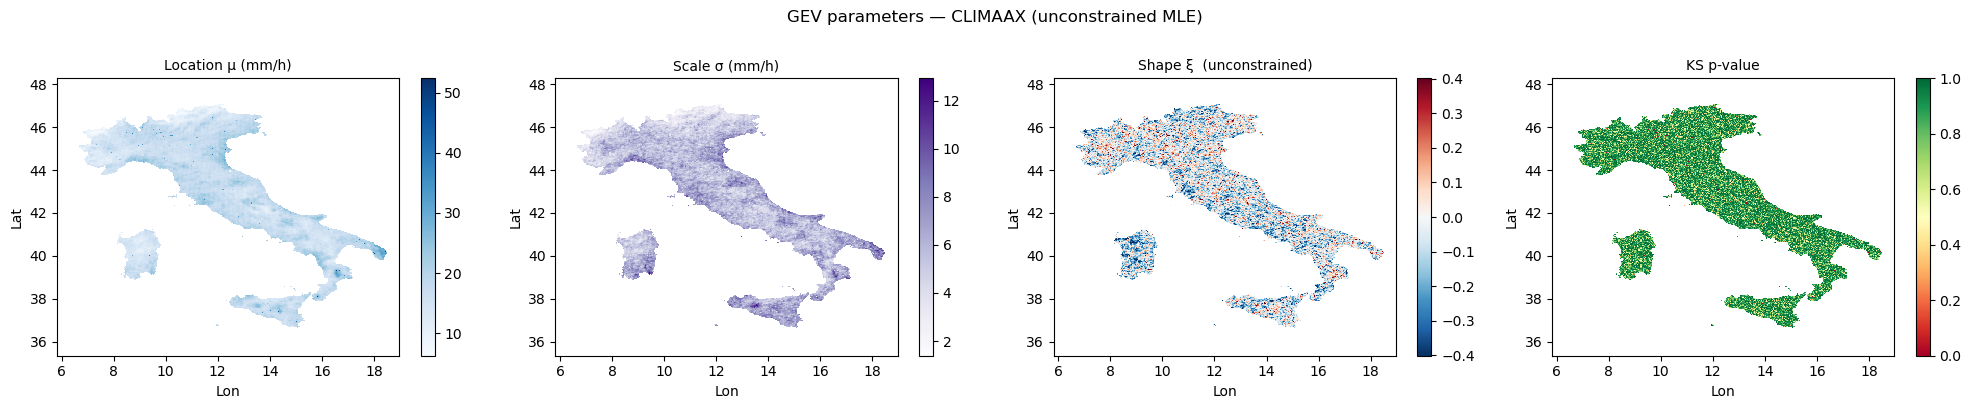

Saved: 01_gev_parameters_climaax.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

titles = ['Location μ (mm/h)', 'Scale σ (mm/h)', 'Shape ξ  (unconstrained)', 'KS p-value']
cmaps  = ['Blues', 'Purples', 'RdBu_r', 'RdYlGn']
data   = [gev_loc, gev_scale, gev_shape, ks_pval]
sh_abs = float(np.nanpercentile(np.abs(gev_shape[~np.isnan(gev_shape)]), 98))

for k, (ax, arr, t, c) in enumerate(zip(axes, data, titles, cmaps)):
    kw = dict(cmap=c, shading='auto')
    if k == 2:
        kw.update(vmin=-sh_abs, vmax=sh_abs)
    elif k == 3:
        kw.update(vmin=0, vmax=1)
    im = ax.pcolormesh(lon_ref, lat_ref, arr, **kw)
    plt.colorbar(im, ax=ax)
    ax.set_title(t, fontsize=10)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

plt.suptitle('GEV parameters — CLIMAAX (unconstrained MLE)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_gev_parameters_climaax.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_gev_parameters_climaax.png")


## 5 · Return period quantile maps — CLIMAAX frequency-factor method

CLIMAAX's `adjust_extreme_prec` computes return values using the **Chow (1988)
frequency factor** approach rather than the exact GEV inverse CDF.

The formula (Chow 1988, Applied Hydrology §12.3):

For `ξ ≠ 0` (GEV type II/III), it works in **log space**:
```
data = log(ann_max)
K(T) = −√6/π · [0.5772 + ln(ln(T/(T−1)))]
Q(T) = exp(mean(data) + K(T) · std(data))
```

For `ξ = 0` (Gumbel), it works in **original space**:
```
Q(T) = mean(data) + K(T) · std(data)
```

Confidence intervals (95%, analytical normal approximation):
```
n_level = 1.96²
a = 1 − n_level / (2(n−1))
b = K² − n_level/n
K_upper = K + √(K² − a·b)
K_lower = K − √(K² − a·b)
CI_upper = exp(mean + std · K_upper / a)     [log space]
CI_lower = exp(mean + std · K_lower / a)
```


In [7]:
def climaax_return_value(ts_1d, shape, return_periods=None):
    """
    CLIMAAX `adjust_extreme_prec` logic applied to a 1-D pixel series.

    Uses the Chow (1988) frequency-factor formula — NOT the exact GEV
    inverse CDF.  This matches the CLIMAAX notebook behaviour exactly.

    Parameters
    ----------
    ts_1d          : 1-D array of annual maxima (mm)
    shape          : fitted GEV shape parameter (determines log vs linear space)
    return_periods : array of return periods in years

    Returns
    -------
    rv   : array shape (len(return_periods),) — return values (mm)
    ci_lo: lower 95% CI
    ci_hi: upper 95% CI
    """
    if return_periods is None:
        return_periods = np.asarray([2, 5, 10, 25, 50, 100, 200])
    rp = np.asarray(return_periods, dtype=float)

    x = ts_1d[~np.isnan(ts_1d)]
    n = len(x)
    if n < MIN_YEARS:
        nan_arr = np.full(len(rp), np.nan)
        return nan_arr, nan_arr, nan_arr

    # CLIMAAX: log space when shape ≠ 0
    if shape != 0:
        data = np.log(x)
    else:
        data = x.copy()

    data_mean = data.mean()
    data_std  = data.std(ddof=0)   # CLIMAAX uses ddof=0

    # Gumbel frequency factor (Chow 1988)
    K = -np.sqrt(6) / np.pi * (0.5772 + np.log(np.log(rp / (rp - 1.0))))

    # 95% CI (normal approximation — Chow 1988)
    n_level = np.power(1.96, 2)
    a = 1.0 - n_level / (2.0 * (n - 1))
    b = K**2 - n_level / n
    discriminant = K**2 - a * b
    discriminant = np.clip(discriminant, 0, None)   # guard sqrt of negative
    K_upper = K + np.sqrt(discriminant)
    K_lower = K - np.sqrt(discriminant)

    rv    = data_mean + K         * data_std
    rv_lo = data_mean + data_std  * K_lower / a
    rv_hi = data_mean + data_std  * K_upper / a

    if shape != 0:
        rv, rv_lo, rv_hi = np.exp(rv), np.exp(rv_lo), np.exp(rv_hi)

    return rv.astype(np.float32), rv_lo.astype(np.float32), rv_hi.astype(np.float32)


# ── Apply pixel-wise ──────────────────────────────────────────────────────────
rp_arr  = np.asarray(RETURN_PERIODS, dtype=float)
nT      = len(RETURN_PERIODS)

rp_maps    = np.full((nT, ny, nx), np.nan, dtype=np.float32)
rp_ci_lo   = np.full((nT, ny, nx), np.nan, dtype=np.float32)
rp_ci_hi   = np.full((nT, ny, nx), np.nan, dtype=np.float32)

print(f"Computing RP maps (CLIMAAX frequency-factor) for {n_italy:,} Italy pixels …")

for j in range(ny):
    for i in range(nx):
        if not italy_mask[j, i] or fit_flag[j, i] == 0:
            continue
        sh = float(gev_shape[j, i])
        rv, rv_lo, rv_hi = climaax_return_value(
            ann_max[:, j, i], sh, RETURN_PERIODS)
        rp_maps[:, j, i]  = rv
        rp_ci_lo[:, j, i] = rv_lo
        rp_ci_hi[:, j, i] = rv_hi

for k, T in enumerate(RETURN_PERIODS):
    arr = rp_maps[k]
    print(f"  RP-{T:>4d}yr: median={np.nanmedian(arr):.1f}  "
          f"p95={np.nanpercentile(arr,95):.1f}  p99={np.nanpercentile(arr,99):.1f}  mm/h")


Computing RP maps (CLIMAAX frequency-factor) for 20,751 Italy pixels …
  RP-   2yr: median=18.3  p95=23.9  p99=27.3  mm/h
  RP-   5yr: median=25.3  p95=33.2  p99=37.9  mm/h
  RP-  10yr: median=31.3  p95=41.7  p99=47.5  mm/h
  RP-  25yr: median=41.0  p95=56.3  p99=64.2  mm/h
  RP-  50yr: median=50.2  p95=71.0  p99=81.5  mm/h
  RP- 100yr: median=61.2  p95=89.7  p99=104.7  mm/h
  RP- 200yr: median=74.6  p95=113.3  p99=135.5  mm/h


## 5.1 · RP map panel

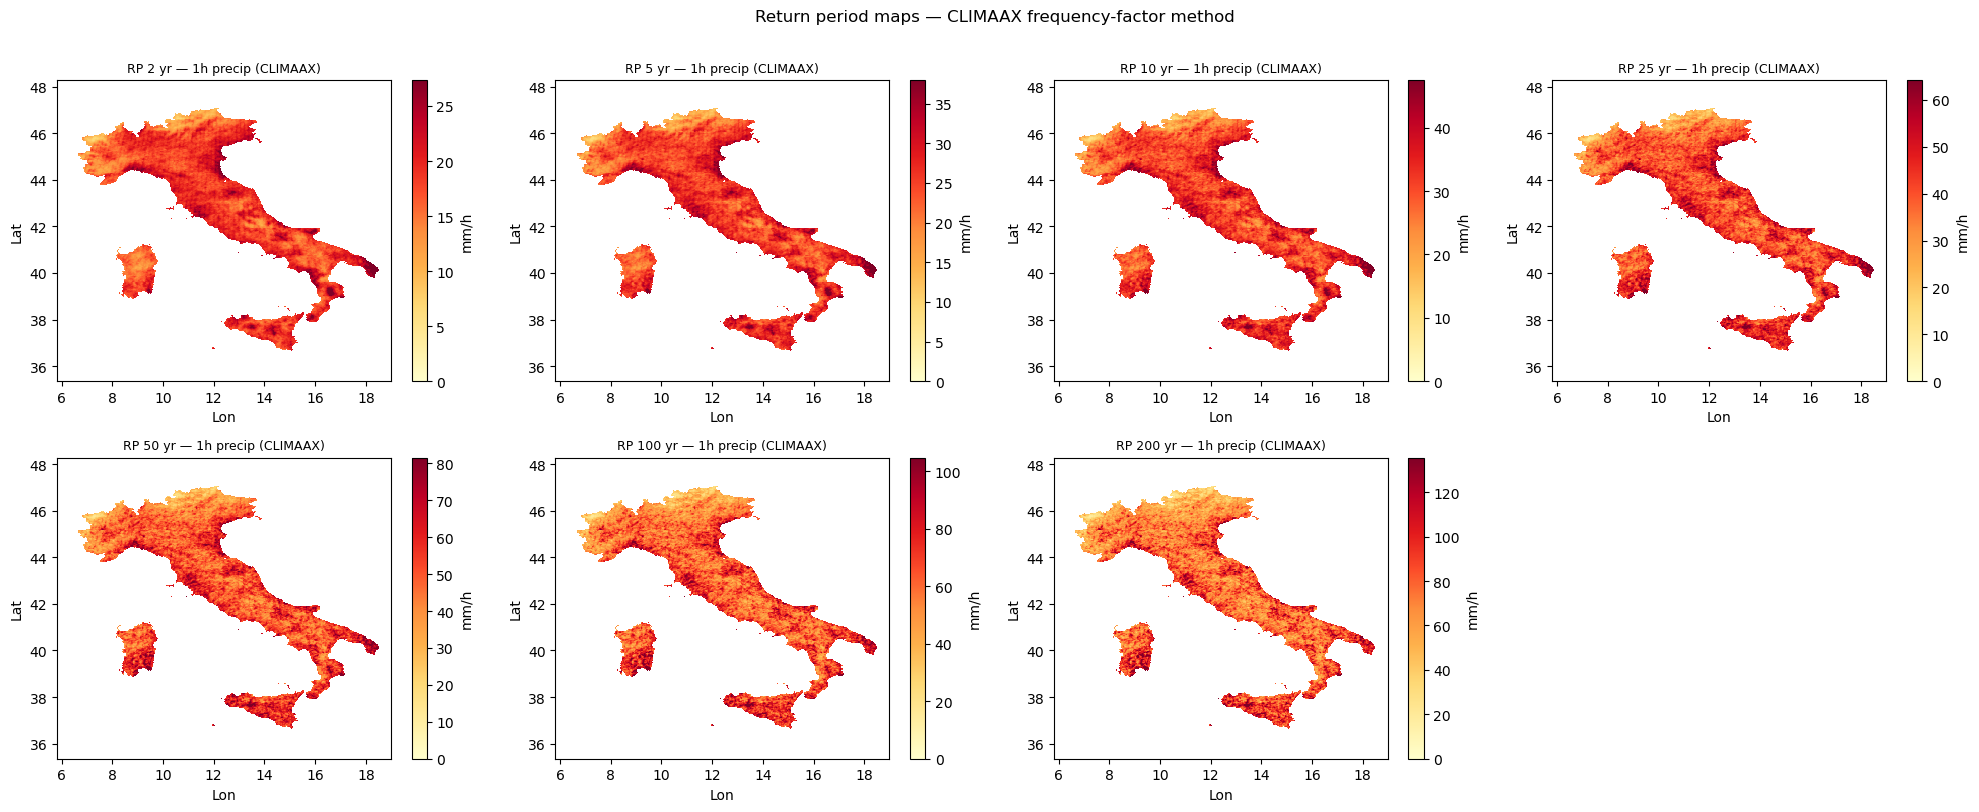

Saved: 02_rp_maps_climaax.png


In [8]:
import math as _math

ncols = 4
nrows = _math.ceil(len(RETURN_PERIODS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()

for ax, T, k in zip(axes, RETURN_PERIODS, range(len(RETURN_PERIODS))):
    arr  = rp_maps[k]
    vmax = float(np.nanpercentile(arr, 99))
    im   = ax.pcolormesh(lon_ref, lat_ref, arr,
                         cmap='YlOrRd', vmin=0, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, label='mm/h')
    ax.set_title(f'RP {T} yr — 1h precip (CLIMAAX)', fontsize=9)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

for ax in axes[len(RETURN_PERIODS):]:
    ax.axis('off')

plt.suptitle('Return period maps — CLIMAAX frequency-factor method', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_rp_maps_climaax.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_rp_maps_climaax.png")


## 6 · Export GeoTIFFs

One LZW-compressed GeoTIFF per return period (EPSG:4326).

In [9]:
dlat  = float(np.abs(np.diff(lat_ref).mean()))
dlon_ = float(np.abs(np.diff(lon_ref).mean()))
west_  = float(lon_ref.min()) - dlon_/2
east_  = float(lon_ref.max()) + dlon_/2
south_ = float(lat_ref.min()) - dlat/2
north_ = float(lat_ref.max()) + dlat/2

transform_out = from_bounds(west_, south_, east_, north_, nx, ny)
needs_flip    = lat_ref[0] < lat_ref[-1]   # ascending → flip for north-up

profile = dict(
    driver='GTiff', dtype='float32', count=1,
    crs='EPSG:4326', transform=transform_out,
    width=nx, height=ny,
    compress='lzw', nodata=float('nan'),
    tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF='IF_SAFER')

for k, T in enumerate(RETURN_PERIODS):
    arr = rp_maps[k].copy()
    if needs_flip:
        arr = arr[::-1]
    path = OUT_DIR / f"MERIDA_HRES_RP{T:03d}yr_1h_climaax.tif"
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(arr[np.newaxis])
    print(f"Saved: {path.name}")

# Also export GEV parameter maps and KS statistic
for name, arr in [("loc", gev_loc), ("scale", gev_scale),
                  ("shape", gev_shape), ("ks_stat", ks_stat), ("ks_pval", ks_pval)]:
    a = arr.copy()
    if needs_flip:
        a = a[::-1]
    path = OUT_DIR / f"MERIDA_HRES_GEV_{name}_climaax.tif"
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(a[np.newaxis])
print("All GeoTIFFs exported.")


Saved: MERIDA_HRES_RP002yr_1h_climaax.tif
Saved: MERIDA_HRES_RP005yr_1h_climaax.tif
Saved: MERIDA_HRES_RP010yr_1h_climaax.tif
Saved: MERIDA_HRES_RP025yr_1h_climaax.tif
Saved: MERIDA_HRES_RP050yr_1h_climaax.tif
Saved: MERIDA_HRES_RP100yr_1h_climaax.tif
Saved: MERIDA_HRES_RP200yr_1h_climaax.tif
All GeoTIFFs exported.


## 7 · Validation at example point (Milan)

Shows:
- Empirical annual maxima (Weibull plotting positions)
- **CLIMAAX frequency-factor** fitted curve + 95% CI
- **v5 exact GEV quantile** curve (Coles 2001) for comparison


Nearest grid: (45.450°N, 9.200°E)


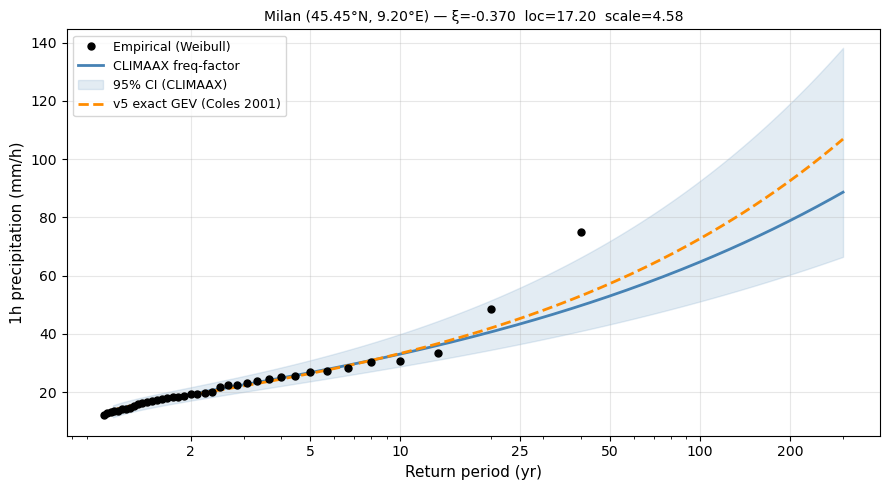

Saved: 03_validation_milan_climaax.png


In [10]:
POINT_LAT = 45.46   # Milan area — change as needed
POINT_LON =  9.19

ji = int(np.argmin(np.abs(lat_ref - POINT_LAT)))
ii = int(np.argmin(np.abs(lon_ref - POINT_LON)))
actual_lat = float(lat_ref[ji])
actual_lon = float(lon_ref[ii])
print(f"Nearest grid: ({actual_lat:.3f}°N, {actual_lon:.3f}°E)")

series_pt = ann_max[:, ji, ii]
valid_pt  = np.sort(series_pt[~np.isnan(series_pt)])
n_pt      = len(valid_pt)
loc_pt    = float(gev_loc[ji, ii])
sc_pt     = float(gev_scale[ji, ii])
sh_pt     = float(gev_shape[ji, ii])

# ── Empirical return periods (Weibull plotting positions) ─────────────────────
ranks   = np.arange(1, n_pt + 1)
T_emp   = (n_pt + 1) / (n_pt + 1 - ranks)   # Weibull: T = (n+1)/(n+1-rank)

# ── CLIMAAX frequency-factor curve ────────────────────────────────────────────
T_plot  = np.logspace(np.log10(1.1), np.log10(300), 200)
rv_cl, rv_lo_cl, rv_hi_cl = climaax_return_value(series_pt, sh_pt, T_plot)

# ── v5 exact GEV quantile (Coles 2001) ───────────────────────────────────────
def gev_quantile(loc, scale, shape, T):
    y = -np.log(1.0 - 1.0/T)
    safe_shape = np.where(np.abs(shape) < 1e-6, 1.0, shape)
    q = np.where(
        np.abs(shape) < 1e-6,
        loc - scale * np.log(y),
        loc - scale / safe_shape * (y**safe_shape - 1.0))
    return np.where(np.isnan(loc), np.nan, q).astype(np.float32)

rv_exact = gev_quantile(np.float32(loc_pt), np.float32(sc_pt),
                         np.float32(sh_pt), T_plot)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(T_emp, valid_pt, 'o', color='black', ms=5, label='Empirical (Weibull)', zorder=5)
ax.semilogx(T_plot, rv_cl, '-',  color='steelblue', lw=2, label='CLIMAAX freq-factor')
ax.fill_between(T_plot, rv_lo_cl, rv_hi_cl, color='steelblue', alpha=0.15, label='95% CI (CLIMAAX)')
ax.semilogx(T_plot, rv_exact, '--', color='darkorange', lw=2, label='v5 exact GEV (Coles 2001)')

ax.set_xlabel('Return period (yr)', fontsize=11)
ax.set_ylabel('1h precipitation (mm/h)', fontsize=11)
ax.set_title(f'Milan ({actual_lat:.2f}°N, {actual_lon:.2f}°E) — '
             f'ξ={sh_pt:+.3f}  loc={loc_pt:.2f}  scale={sc_pt:.2f}', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks([2,5,10,25,50,100,200])
ax.set_xticklabels([2,5,10,25,50,100,200])

plt.tight_layout()
plt.savefig(OUT_DIR / "03_validation_milan_climaax.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_validation_milan_climaax.png")


## 8 · Quantitative comparison: CLIMAAX freq-factor vs v5 exact GEV

This cell computes, for each Italy land pixel, the **percentage difference**
between the two RP estimates:

```
diff(%) = 100 × (CLIMAAX − Exact) / Exact
```

Large positive differences mean CLIMAAX over-estimates; large negative mean
it under-estimates, relative to the theoretically correct formula.

The difference grows with:
- Return period (longer RP → more extrapolation → formula divergence amplified)
- `|ξ|` (shape farther from zero → log-space approximation breaks down more)


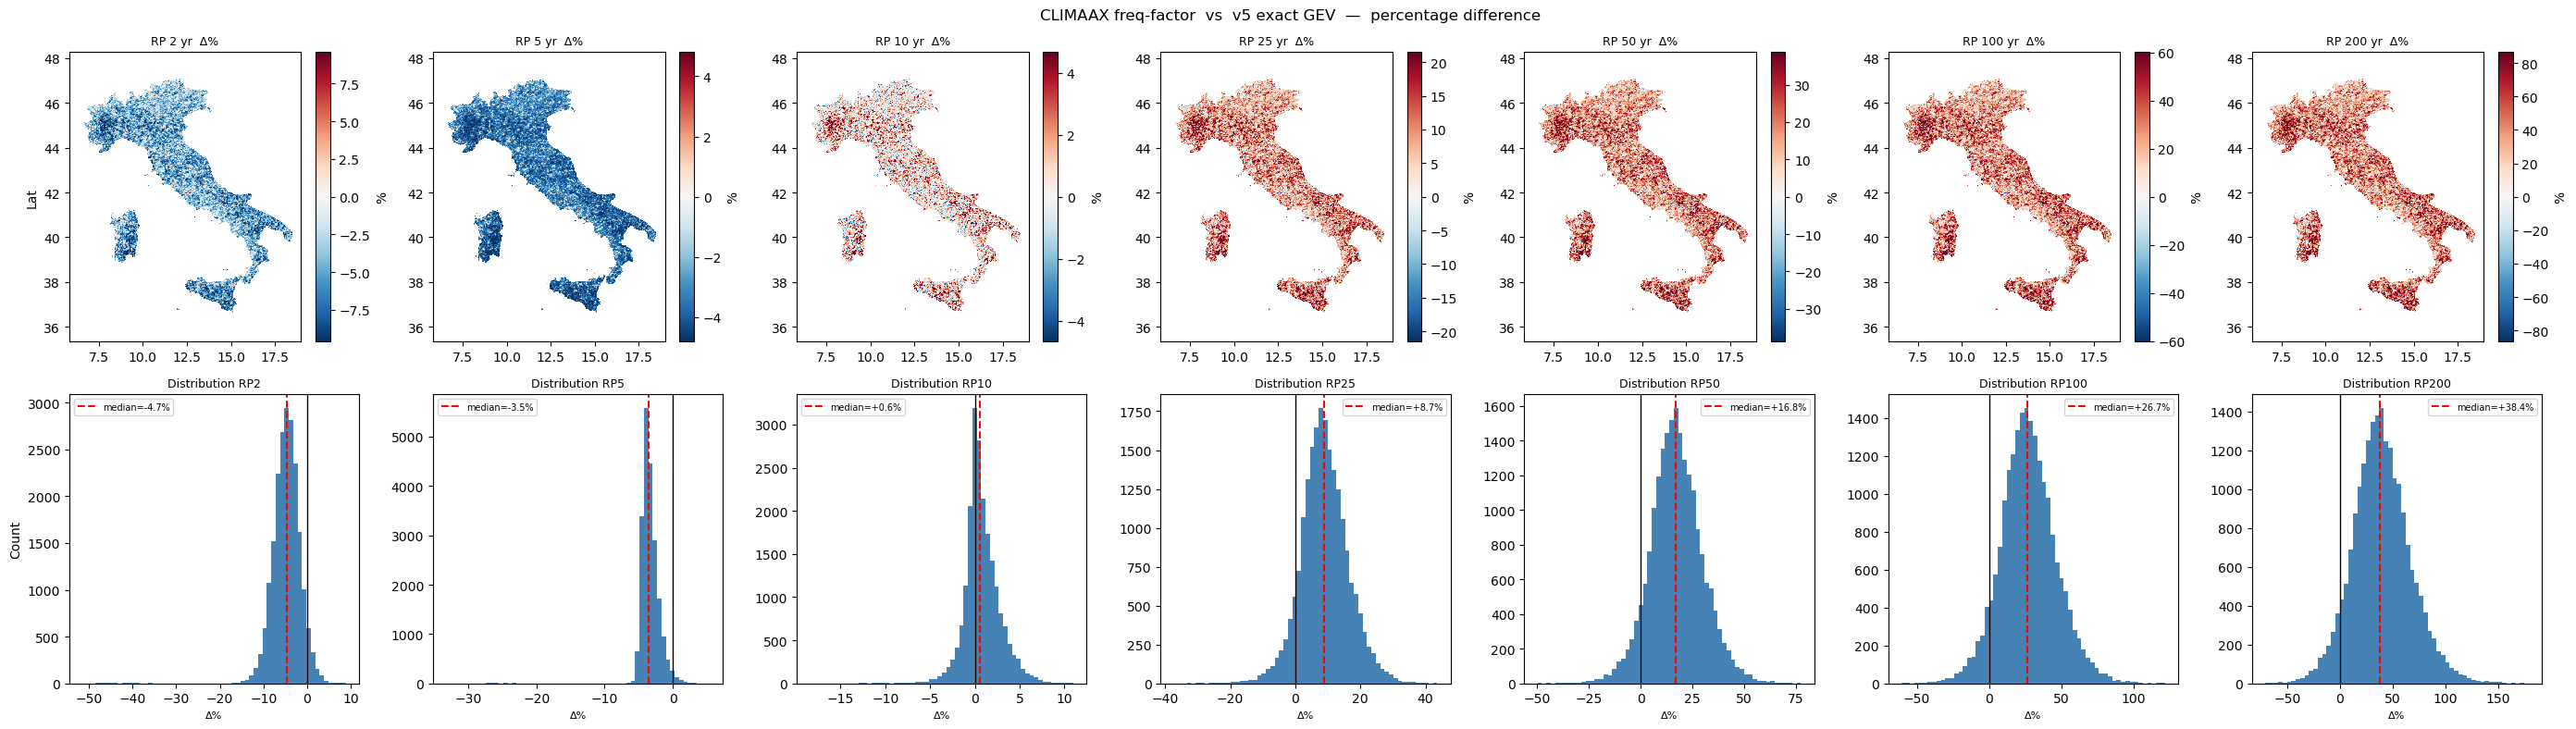

Saved: 04_comparison_climaax_vs_exact.png

Median |Δ%| by return period (Italy land pixels):
      RP   median Δ%    p95 |Δ|%
       2       -4.68         9.6
       5       -3.51         4.8
      10       +0.55         4.7
      25       +8.72        21.5
      50      +16.85        38.7
     100      +26.72        60.1
     200      +38.38        86.6


In [11]:
# Recompute v5 exact RP maps on Italy pixels for comparison
rp_exact = {}
for T in RETURN_PERIODS:
    rp_exact[T] = gev_quantile(gev_loc, gev_scale, gev_shape, T)

fig, axes = plt.subplots(2, len(RETURN_PERIODS),
                         figsize=(4*len(RETURN_PERIODS), 8))

for k, T in enumerate(RETURN_PERIODS):
    cl  = rp_maps[k]
    ex  = rp_exact[T]
    diff_pct = np.where(ex > 0.1, 100*(cl - ex)/ex, np.nan)

    vabs = float(np.nanpercentile(np.abs(diff_pct), 95))
    vabs = max(vabs, 1.0)

    # Difference map
    im = axes[0, k].pcolormesh(lon_ref, lat_ref, diff_pct,
                                cmap='RdBu_r', vmin=-vabs, vmax=vabs, shading='auto')
    plt.colorbar(im, ax=axes[0, k], label='%')
    axes[0, k].set_title(f'RP {T} yr  Δ%', fontsize=9)

    # Histogram
    vals = diff_pct[~np.isnan(diff_pct)].ravel()
    axes[1, k].hist(vals, bins=60, color='steelblue', edgecolor='none')
    axes[1, k].axvline(0, color='black', lw=1)
    axes[1, k].axvline(np.nanmedian(vals), color='red', lw=1.5, linestyle='--',
                        label=f'median={np.nanmedian(vals):+.1f}%')
    axes[1, k].set_xlabel('Δ%', fontsize=8)
    axes[1, k].set_title(f'Distribution RP{T}', fontsize=9)
    axes[1, k].legend(fontsize=7)

axes[0, 0].set_ylabel('Lat')
axes[1, 0].set_ylabel('Count')
plt.suptitle('CLIMAAX freq-factor  vs  v5 exact GEV  —  percentage difference', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_comparison_climaax_vs_exact.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_comparison_climaax_vs_exact.png")

# Print summary table
print("\nMedian |Δ%| by return period (Italy land pixels):")
print(f"  {'RP':>6}  {'median Δ%':>10}  {'p95 |Δ|%':>10}")
for k, T in enumerate(RETURN_PERIODS):
    cl  = rp_maps[k]
    ex  = rp_exact[T]
    diff_pct = np.where(ex > 0.1, 100*(cl - ex)/ex, np.nan)
    vals = diff_pct[~np.isnan(diff_pct)].ravel()
    print(f"  {T:>6}  {np.nanmedian(vals):>+10.2f}  {np.nanpercentile(np.abs(vals),95):>10.1f}")


## 9 · Run summary

In [12]:
print('='*65)
print('MERIDA HRES — CLIMAAX-style RP maps: Run complete')
print('='*65)
print(f'Dataset         : {df_inv.year.min()}–{df_inv.year.max()} '
      f'({n_years} years, {len(df_inv)} monthly files)')
print(f'Grid            : {ny} × {nx} = {ny*nx:,} pixels total')
print(f'Italy land mask : {n_italy:,} pixels ({100*n_italy/(ny*nx):.1f}% of grid)')
print(f'Duration        : {DURATION_H} h')
print()
print('GEV fitting (CLIMAAX approach):')
print(f'  Estimator       : MLE only (scipy.genextreme.fit)')
print(f'  Shape constraint: NONE (unconstrained)')
print(f'  Fitted OK       : {n_ok:,} pixels')
print(f'  KS p > 0.05     : {n_good_ks:,} ({100*n_good_ks/max(n_ok,1):.1f}% of fitted)')
print(f'  KS p <= 0.05    : {n_poor_ks:,} ({100*n_poor_ks/max(n_ok,1):.1f}% of fitted) — poor fit flag')
print(f'  MLE failed      : {n_fail:,}')
print(f'  ξ range         : [{np.nanmin(gev_shape):.3f}, {np.nanmax(gev_shape):.3f}]  median={np.nanmedian(gev_shape):.3f}')
print()
print('RP formula      : Chow (1988) log-space frequency factor')
print('CI method       : analytical normal approximation (95%)')
print()
print('Output GeoTIFFs (EPSG:4326, LZW compressed):')
for T in RETURN_PERIODS:
    p = OUT_DIR / f"MERIDA_HRES_RP{T:03d}yr_1h_climaax.tif"
    sz = p.stat().st_size/1e6 if p.exists() else 0
    print(f'  RP{T:>4d}yr  →  {p.name}  ({sz:.1f} MB)')


MERIDA HRES — CLIMAAX-style RP maps: Run complete
Dataset         : 1986–2024 (39 years, 468 monthly files)
Grid            : 323 × 329 = 106,267 pixels total
Italy land mask : 20,751 pixels (19.5% of grid)
Duration        : 1 h

GEV fitting (CLIMAAX approach):
  Estimator       : MLE only (scipy.genextreme.fit)
  Shape constraint: NONE (unconstrained)
  Fitted OK       : 20,751 pixels
  KS p > 0.05     : 20,689 (99.7% of fitted)
  KS p <= 0.05    : 62 (0.3% of fitted) — poor fit flag
  MLE failed      : 0
  ξ range         : [-0.770, 3.420]  median=-0.061

RP formula      : Chow (1988) log-space frequency factor
CI method       : analytical normal approximation (95%)

Output GeoTIFFs (EPSG:4326, LZW compressed):
  RP   2yr  →  MERIDA_HRES_RP002yr_1h_climaax.tif  (0.1 MB)
  RP   5yr  →  MERIDA_HRES_RP005yr_1h_climaax.tif  (0.1 MB)
  RP  10yr  →  MERIDA_HRES_RP010yr_1h_climaax.tif  (0.1 MB)
  RP  25yr  →  MERIDA_HRES_RP025yr_1h_climaax.tif  (0.1 MB)
  RP  50yr  →  MERIDA_HRES_RP050yr_1h